In [1]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
import sqlite3

In [2]:
# LOAD DATASET

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

In [3]:
# RISK SCORING MODEL

df["risk_score"] = df.iloc[:, :5].mean(axis=1) * 10

df["risk_category"] = pd.cut(
    df["risk_score"],
    bins=[0, 10, 20, 30],
    labels=["Low", "Medium", "High"]
)

In [4]:
# SQL ANALYTICS

conn = sqlite3.connect("risk.db")
df.to_sql("saas_risk", conn, if_exists="replace", index=False)

query = """
SELECT risk_category, COUNT(*) as total
FROM saas_risk
GROUP BY risk_category
"""

result = pd.read_sql(query, conn)
print(result)

  risk_category  total
0          None    569


In [5]:
# EXPORTING RESULTS

df.to_csv("saas_risk_dashboard.csv", index=False)

In [6]:
import matplotlib.pyplot as plt

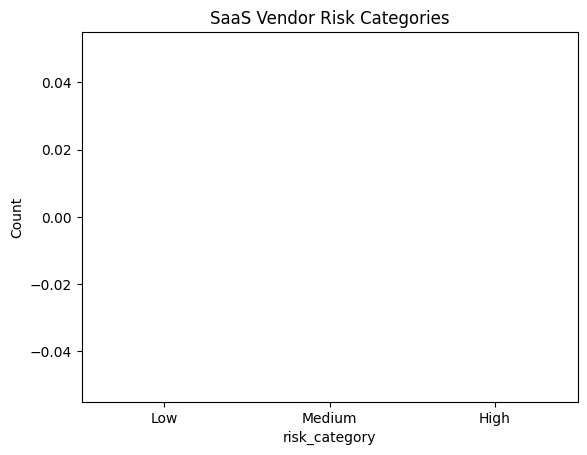

In [7]:
# RISK CATEGORY DISTRIBUTION

plt.figure()
df["risk_category"].value_counts().plot(kind="bar")
plt.title("SaaS Vendor Risk Categories")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

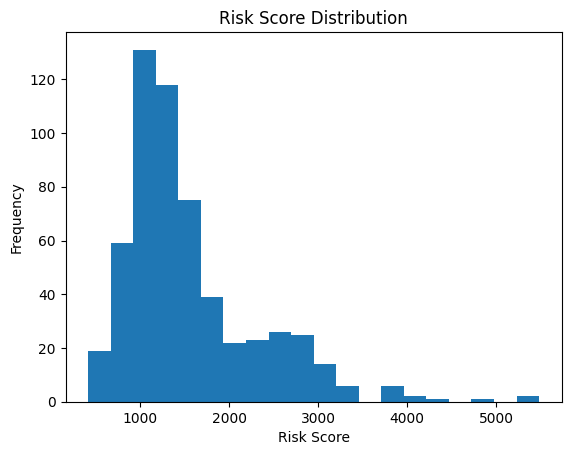

In [8]:
# RISK SCORE DISTRIBUTION

plt.figure()
plt.hist(df["risk_score"], bins=20)
plt.title("Risk Score Distribution")
plt.xlabel("Risk Score")
plt.ylabel("Frequency")
plt.show()

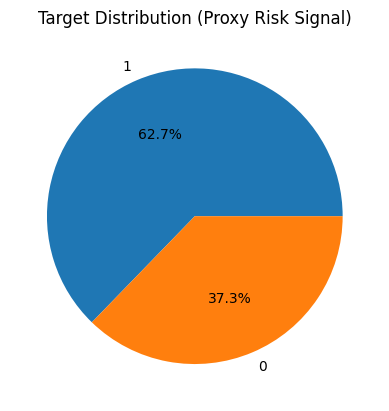

In [9]:
# TARGET DISTRIBUTION

plt.figure()
df["target"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Target Distribution (Proxy Risk Signal)")
plt.ylabel("")
plt.show()